In [1]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torch import nn
import pathlib 
import os
import torch
from PIL import Image
from pathlib import Path
import random
import torchvision.models as model
from torchvision.models import resnet18, ResNet18_Weights
from tqdm import tqdm

In [2]:
device="cuda"
data_path = Path("data/")
image_path = data_path/"Dataset_2"

def walk_through_files(dir_path):

    for dirpath,dirnames,files in os.walk(dir_path):
        print(f"Currently there are {len(files)} files and {len(dirnames)} directories in {dirpath}")

In [3]:
walk_through_files(image_path)

Currently there are 0 files and 2 directories in data\Dataset_2
Currently there are 0 files and 2 directories in data\Dataset_2\Test
Currently there are 5492 files and 0 directories in data\Dataset_2\Test\Fake
Currently there are 5413 files and 0 directories in data\Dataset_2\Test\Real
Currently there are 0 files and 2 directories in data\Dataset_2\Train
Currently there are 70001 files and 0 directories in data\Dataset_2\Train\Fake
Currently there are 70001 files and 0 directories in data\Dataset_2\Train\Real


In [4]:
train_dir = image_path/"train"
test_dir = image_path/"test"

Image Class:Real
Image path:data\Dataset_2\Train\Real\real_36637.jpg
Image Height:256
Image Weidth:256
Image Shape:(256, 256, 3)


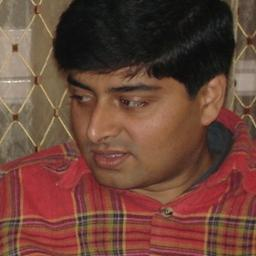

In [5]:
image_list = list(image_path.glob("*/*/*.jpg"))

pick_img = random.choice(image_list)
class_name = pick_img.parent.stem
img = Image.open(pick_img)
image_as_array = np.array(img)

print(f"Image Class:{class_name}")
print(f"Image path:{pick_img}")
print(f"Image Height:{img.height}")
print(f"Image Weidth:{img.width}")
print(f"Image Shape:{image_as_array.shape}")
img

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAdjustSharpness(2, p=0.5),
    transforms.GaussianBlur(3),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(p=0.2),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7411594..1.923538].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606442..2.0822659].


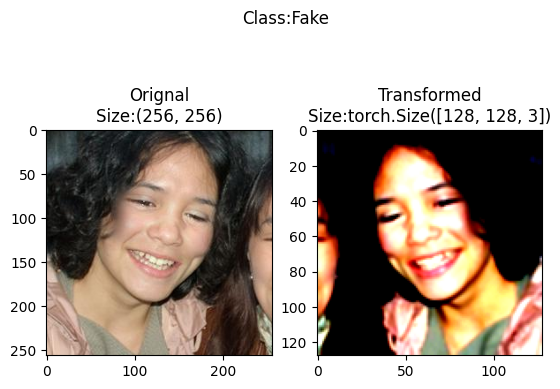

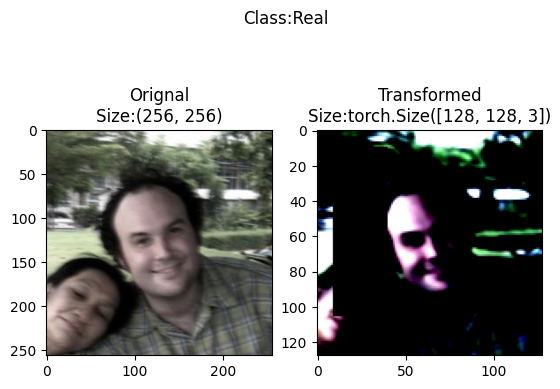

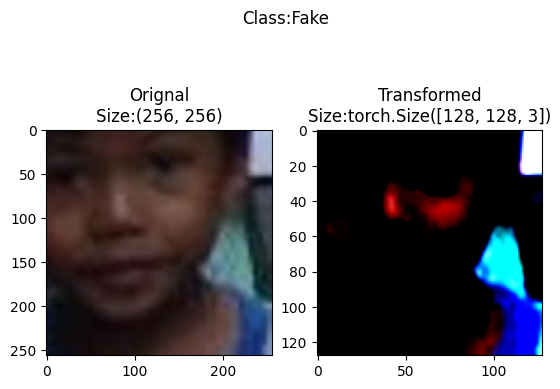

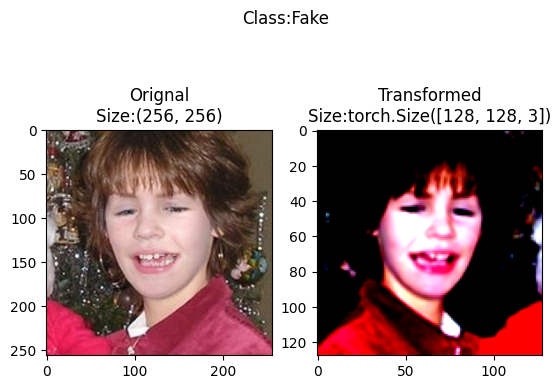

In [7]:
def plot_transformed_images(image_list,transformed,seed=42):

    random.seed(seed)
    random_pick = random.sample(image_list,k=4)

    for imgs_1 in random_pick:
        with Image.open(imgs_1) as f:
            fig,ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f"Orignal\nSize:{f.size}")

            transformed_img = transformed(f).permute(1,2,0)
            ax[1].imshow(transformed_img)
            ax[1].set_title(f"Transformed\nSize:{transformed_img.shape}")

            fig.suptitle(f"Class:{imgs_1.parent.stem}")

plot_transformed_images(image_list,train_transform)

In [8]:
train_data = datasets.ImageFolder(root=train_dir,transform=train_transform)

test_data = datasets.ImageFolder(root=test_dir,transform=test_transform)
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 140002
     Root location: data\Dataset_2\train
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                RandomAdjustSharpness(sharpness_factor=2,p=0.5)
                GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
                ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
                ToTensor()
                RandomErasing(p=0.2, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset ImageFolder
     Number of datapoints: 10905
     Root location: data\Dataset_2\test
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
   

In [9]:
BATCH_SZIE  = 32

train_data_loader = DataLoader(dataset=train_data,batch_size=BATCH_SZIE,shuffle=True,num_workers=2,pin_memory=True)
test_data_loader = DataLoader(dataset=test_data,batch_size=BATCH_SZIE,shuffle=False,num_workers=2,pin_memory=True)

train_data_loader,test_data_loader

(<torch.utils.data.dataloader.DataLoader at 0x1bfea115400>,
 <torch.utils.data.dataloader.DataLoader at 0x1bfed4af9d0>)

In [10]:
class_names = train_data.class_to_idx
class_names

{'Fake': 0, 'Real': 1}

In [11]:
model_0 = model.resnet18(weights=ResNet18_Weights.DEFAULT)
model_0.fc = nn.Linear(model_0.fc.in_features, 2)
model_0.to(device)
model_0

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [12]:
from helper_functions import accuracy_fn

loss_func = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.1)
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.003)

In [13]:
torch.manual_seed(42)
def train_step(data_loader, model, optimizer, accuracy_fn, loss_fnc, device='cuda'):
    train_loss, train_accuracy = 0, 0

    model.train()  

    for batch, (x, y) in enumerate(data_loader):
        x, y = x.to(device), y.to(device)

        # Forward
        outputs = model(x)

        # Loss
        loss = loss_fnc(outputs, y)
        train_loss += loss.item()

        # Accuracy
        y_pred = outputs.argmax(dim=1)
        train_accuracy += accuracy_fn(y_true=y, y_pred=y_pred)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_accuracy /= len(data_loader)

    print(f"Train loss:{train_loss:.4f} || Train Accuracy:{train_accuracy:.4f}")
    return train_loss, train_accuracy

def test_step(data_loader, model, accuracy_fn, loss_fnc, device='cuda'):
    test_loss, test_acc = 0, 0

    model.eval()

    with torch.inference_mode():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)

            test_loss += loss_fnc(outputs, y).item()

            y_pred = outputs.argmax(dim=1)
            test_acc += accuracy_fn(y_true=y, y_pred=y_pred)

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test Loss:{test_loss:.4f} || Test Accuracy:{test_acc:.4f}")
    return test_loss, test_acc

In [14]:
img_batch,label_batch = next(iter(train_data_loader))

img_single,label_single = img_batch[0].unsqueeze(dim=0),label_batch[0]

print(f"Shape of Img:{img_single.shape}\n")

with torch.inference_mode():
    pred = model_0(img_single.to(device))

print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Shape of Img:torch.Size([1, 3, 128, 128])

Output logits:
tensor([[0.7740, 1.0437]], device='cuda:0')

Output prediction probabilities:
tensor([[0.4330, 0.5670]], device='cuda:0')

Output prediction label:
tensor([1], device='cuda:0')

Actual label:
1


In [15]:
torch.manual_seed(42)
epochs = 5

train_loss_list = []
train_acc_list = []
test_acc_list = []

for epoch in tqdm(range(epochs)):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_step(train_data_loader, model_0, optimizer,accuracy_fn, loss_func)
    test_loss, test_acc = test_step(test_data_loader, model_0,accuracy_fn,loss_func)

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")
    

  0%|          | 0/5 [00:00<?, ?it/s]


Epoch 1/5
Train loss:0.2782 || Train Accuracy:87.4457


 20%|██        | 1/5 [21:34<1:26:19, 1294.80s/it]

Test Loss:0.4269 || Test Accuracy:76.9769
Train Loss: 0.2782 | Train Acc: 87.4457
Test  Loss: 0.4269 | Test  Acc: 76.9769

Epoch 2/5
Train loss:0.1730 || Train Accuracy:92.9202


 40%|████      | 2/5 [25:13<33:05, 661.88s/it]   

...

Test Loss:0.3321 || Test Accuracy:83.6785
Train Loss: 0.1427 | Train Acc: 94.0878
Test  Loss: 0.3321 | Test  Acc: 83.6785

Epoch 4/5
Train loss:0.1242 || Train Accuracy:94.8933


 80%|████████  | 4/5 [32:38<06:06, 366.77s/it]

Test Loss:0.4058 || Test Accuracy:78.8215
Train Loss: 0.1242 | Train Acc: 94.8933
Test  Loss: 0.4058 | Test  Acc: 78.8215

Epoch 5/5
Train loss:0.1122 || Train Accuracy:95.2911


100%|██████████| 5/5 [36:19<00:00, 435.87s/it]

Test Loss:0.2513 || Test Accuracy:89.2086
Train Loss: 0.1122 | Train Acc: 95.2911
Test  Loss: 0.2513 | Test  Acc: 89.2086


In [ ]:
from pathlib import Path
import torch

# Create models directory
MODEL_PATH = Path("Models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Dataset_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)
# best_acc = 0
# model_path = Path("Models")
# model_path.mkdir(parents=True, # create parent directories if needed
#                  exist_ok=True # if models directory already exists, don't error
# )

# model_name = "best_model.pth"
# model_save_path = model_path / model_name

# for epoch in range(epochs):
#     train_loss, train_acc = train_step(...)
#     test_loss, test_acc = test_step(...)

#     if test_acc > best_acc:
#         best_acc = test_acc
#         torch.save(model_0.state_dict(), model_save_path)

In [1]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda"

model_loaded = models.resnet18(weights=None)
model_loaded.fc = nn.Linear(model_loaded.fc.in_features, 2)

model_loaded.load_state_dict(torch.load("Models/Dataset_2.pth"))
model_loaded.to(device)
model_loaded.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
from PIL import Image
from torchvision import transforms
import numpy as np
import torch

device = "cuda"
img_path = "data/test_1.jpg"

def prediction(img_path:str,class_name:list):

    img_test = Image.open(img_path)
    transform_img_for_test = transforms.Compose([    
    transforms.Resize((128,128)),
    transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
    ])
    
    transform_1 = transform_img_for_test(img_test).unsqueeze(0).to(device)
    with torch.inference_mode():
        logits = model_loaded(transform_1)
        probs = torch.softmax(logits,dim=1)
        pred_class_indx = torch.argmax(probs,dim=1).item()
        confidence = probs[0][pred_class_indx].item()

    print(f"CLass name:{class_name[pred_class_indx]}")
    print(f"Confidence Score:{confidence:.2%}")
    return class_names[pred_class_indx], confidence

class_names = ["Fake","Real"]
prediction(img_path,class_names)


CLass name:Real
Confidence Score:91.73%


('Real', 0.91729736328125)